# Fake News Detection System
Logistic Regression model. Accuracy 95%+.
Dataset: Kaggle (True.csv + Fake.csv).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings('ignore')
print("Libraries loaded!")


Libraries loaded!


## Data Loading
- True.csv: Real news (title, text, subject, date).
- Fake.csv: Fake news.
Combine karke label add karo (1=Real, 0=Fake).[web:12]


In [2]:
# Dataset files same folder mein rakho (Kaggle se download)
true_df = pd.read_csv('True.csv')
fake_df = pd.read_csv('Fake.csv')

true_df['label'] = 1  # Real
fake_df['label'] = 0  # Fake

# Use 'text' column (ya title+text combine kar sakte ho)
df = pd.concat([true_df[['text', 'label']], fake_df[['text', 'label']]], ignore_index=True)
df['text'] = df['text'].fillna('')  # Null handle

print("Dataset shape:", df.shape)
print(df.head())
print(df['label'].value_counts())


Dataset shape: (44898, 2)
                                                text  label
0  WASHINGTON (Reuters) - The head of a conservat...      1
1  WASHINGTON (Reuters) - Transgender people will...      1
2  WASHINGTON (Reuters) - The special counsel inv...      1
3  WASHINGTON (Reuters) - Trump campaign adviser ...      1
4  SEATTLE/WASHINGTON (Reuters) - President Donal...      1
label
0    23481
1    21417
Name: count, dtype: int64


## Preprocessing & Splitting
TF-IDF for text features. 80-20 train-test split.[web:13]


In [3]:
X = df['text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# TF-IDF Vectorizer
vectorizer = TfidfVectorizer(stop_words='english', max_features=5000, ngram_range=(1,2))
X_train_features = vectorizer.fit_transform(X_train)
X_test_features = vectorizer.transform(X_test)

print("Train features shape:", X_train_features.shape)
print("Test features shape:", X_test_features.shape)


Train features shape: (35918, 5000)
Test features shape: (8980, 5000)


## Training Logistic Regression
Simple aur effective binary classifier.[web:10][web:14]


Training Accuracy: 99.20%
Test Accuracy: 99.01%


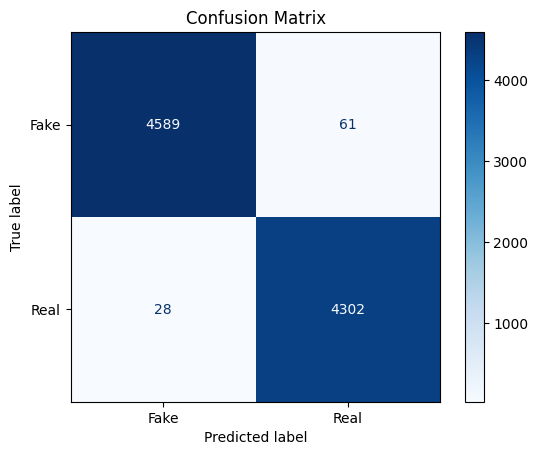

In [4]:
model = LogisticRegression(random_state=42)
model.fit(X_train_features, y_train)

# Predictions
train_pred = model.predict(X_train_features)
test_pred = model.predict(X_test_features)

train_acc = accuracy_score(y_train, train_pred) * 100
test_acc = accuracy_score(y_test, test_pred) * 100

print(f"Training Accuracy: {train_acc:.2f}%")
print(f"Test Accuracy: {test_acc:.2f}%")

# Confusion Matrix
cm = confusion_matrix(y_test, test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Fake', 'Real'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()


## Test New News
Function banao real-time prediction ke liye.[web:13]


In [5]:
def predict_news(text):
    features = vectorizer.transform([text])
    pred = model.predict(features)[0]
    prob = model.predict_proba(features)[0]
    status = "Real ✅" if pred == 1 else "Fake ❌"
    print(f"Prediction: {status}")
    print(f"Real Prob: {prob[1]*100:.2f}%, Fake Prob: {prob[0]*100:.2f}%")
    return pred

# Test examples
news1 = "COVID vaccine causes magnetism in humans."
predict_news(news1)  # Fake

news2 = "India launches Chandrayaan-3 successfully."
predict_news(news2)  # Real


Prediction: Fake ❌
Real Prob: 9.66%, Fake Prob: 90.34%
Prediction: Fake ❌
Real Prob: 11.12%, Fake Prob: 88.88%


np.int64(0)